# 循環神經網路

## 沒有記憶功能的非循環神經網路

函式 f(x) 每次被呼叫時，第一行永遠是 y = 0

這意味著：無論你上一秒輸入的是 $2$ 還是 $100$，這一次的運算都從零開始。

它不關心過去（History-independent），這就是非循環神經網路（Non-recurrent Neural Network） 的核心特性。

In [140]:
def f(x):
    y = 0
    y += x ** 2
    return y

print(f(2), '\t', f(3))
print(f(3), '\t', f(4))

4 	 9
9 	 16


## 沒有記憶功能的非循環神經網路

這段程式碼模擬了 RNN 的簡化數學模型： $y_{t}, h_{t} = f(x_{t}, h_{t-1})$

隱藏層公式： $h_t = h_{t-1} + w_x \cdot x_t$，權重設定為 $w_x = 2$。

輸出層公式： $y_t = h_t + f(x_t)$，$f(x_t) = x^2$。

這種結構讓網路能夠處理序列型數據（如文字、股價、語音）。例如在翻譯時，網路必須記得前面的單字是「我」，後面的動詞才會選擇對應的變化。

In [141]:
class rf():
    def __init__(self):
        self.h = 0

    def forward(self, x):
        self.h += 2 * x
        return self.h + x ** 2
    
    def __call__(self, x):
        return self.forward(x)
    
f = rf()
print(f(2), '\t', f(3))
print(f(3), '\t', f(2))

8 	 19
25 	 24


## 初始化模型參數

In [142]:
import numpy as np

np.random.seed(1)

def rnn_params_init(input_dim, hidden_dim, output_dim, scale = 0.01):        
    # Input → Hidden 權重
    Wx = np.random.randn(input_dim, hidden_dim) * scale 
    
    # Hidden → Hidden 權重（時間上的遞迴連結）
    Wh = np.random.randn(hidden_dim, hidden_dim) * scale 
    
    # Hidden 層偏置
    bh = np.zeros((1, hidden_dim)) 

    # Hidden → Output 權重
    Wf = np.random.randn(hidden_dim, output_dim) * scale 
    
    # Output 層偏置
    bf = np.zeros((1, output_dim)) 

    # 回傳所有參數
    return [Wx, Wh, bh, Wf, bf]


def rnn_hidden_state_init(batch_dim, hidden_dim):
    # 初始化 hidden state（通常一開始設為 0）
    return np.zeros((batch_dim, hidden_dim))

## 定義資料

一段長度為 5 的序列資料 (T)，每個時間點有 4 個數值特徵。

In [143]:
import numpy as np

np.random.seed(1)

# 生成 5 個時刻（Time Steps），每批只有 1 個樣本（Batch Size）的一組測試資料
# 我們定義一個 RNN 模型，規格如下：
# Input Dimension: 4 (輸入維度)
# Hidden Dimension: 10 (隱藏層神經元數量)
# Output Dimension: 4 (輸出維度)
if True:
    T = 5
    input_dim, hidden_dim, output_dim = 4, 10, 4
    batch_size = 1
    seq_len = 5
    
    # 隨機生一組輸入 Xs，形狀是 (序列長度, 批次大小, 特徵維度)
    Xs = np.random.rand(seq_len, batch_size, input_dim)
    
    # 隨機生一組正確答案 Ys，通常是用來算 Loss 的「標籤 (Label)」
    # 用整數做分類任務 (Classification)
    Ys = np.random.randint(input_dim, size = (seq_len, batch_size))
    
print("輸入資料 Xs：\n", Xs)
print("輸入資料 Xs 的形狀：", Xs.shape)
print("對應的標籤 Ys：\n", Ys)
print("對應的標籤 Ys 的形狀：", Ys.shape)

輸入資料 Xs：
 [[[4.17022005e-01 7.20324493e-01 1.14374817e-04 3.02332573e-01]]

 [[1.46755891e-01 9.23385948e-02 1.86260211e-01 3.45560727e-01]]

 [[3.96767474e-01 5.38816734e-01 4.19194514e-01 6.85219500e-01]]

 [[2.04452250e-01 8.78117436e-01 2.73875932e-02 6.70467510e-01]]

 [[4.17304802e-01 5.58689828e-01 1.40386939e-01 1.98101489e-01]]]
輸入資料 Xs 的形狀： (5, 1, 4)
對應的標籤 Ys：
 [[1]
 [1]
 [1]
 [3]
 [3]]
對應的標籤 Ys 的形狀： (5, 1)


## 參數模型與隱藏狀態變數初始化

In [144]:
# 模型參數
params = rnn_params_init(input_dim, hidden_dim, output_dim)

print("參數的形狀：", [p.shape for p in params])
print("Wx參數的內容：", params[0])  # Wx 是第一個參數
print("Wh參數的內容：", params[1])  # Wh 是第二個參數
print("bh參數的內容：", params[2])  # bh 是第三個參數
print("Wf參數的內容：", params[3])  # Wf 是第四個參數
print("bf參數的內容：", params[4])  # bf 是第五個參數

參數的形狀： [(4, 10), (10, 10), (1, 10), (10, 4), (1, 4)]
Wx參數的內容： [[ 0.0004026  -0.00903123  0.00175323  0.00194431 -0.00535249  0.00777351
   0.00171338 -0.00442851  0.01704904  0.00924346]
 [-0.01304861 -0.00380575 -0.00743627 -0.00437122 -0.0042645   0.01381407
   0.00098371 -0.00369457 -0.0127322   0.01014987]
 [-0.0148106  -0.002871   -0.00056824 -0.00788105  0.0006771  -0.01038906
  -0.00263677  0.00538251  0.0152826   0.01956677]
 [ 0.004782    0.00119345 -0.00857465 -0.00761948  0.00639305  0.00047526
   0.03114834 -0.00532462  0.00345584 -0.00425514]]
Wh參數的內容： [[-2.23877138e-02  1.75539696e-02 -2.64193363e-03  8.46294467e-03
   2.08673250e-02  5.26478312e-03  9.83809002e-03 -1.92220001e-02
  -8.94825229e-03  3.30062822e-03]
 [ 1.04859100e-02  1.34989935e-02  1.24567511e-02 -6.91191472e-03
   1.28107338e-02 -7.27064310e-03 -7.99168694e-03 -3.54562185e-05
   5.12594636e-03 -1.67860864e-03]
 [ 1.34633628e-02 -6.15491978e-03 -7.43036696e-03  1.01593613e-02
  -5.55155414e-03  4.3625936

In [145]:
# 隱藏狀態變數，這格通常全填 0
H_0 = rnn_hidden_state_init(batch_size, hidden_dim)

print("初始的隱藏狀態 H_0：\n", H_0)
print("初始的隱藏狀態 H_0 的形狀：", H_0.shape)

初始的隱藏狀態 H_0：
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
初始的隱藏狀態 H_0 的形狀： (1, 10)


In [146]:
a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
b = np.array([[1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1],
              [1 ,1, 1, 1, 1, 1, 1, 1, 1, 1]])

np.dot(a, b)

array([55, 55, 55, 55, 55, 55, 55, 55, 55, 55])

## 向前傳播

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

$$y_t = W_y h_t$$

In [147]:
def rnn_forward(params, Xs, H_):
    # 參數
    Wx, Wh, bh, Wf, bf = params
    
    # 初始的隱藏狀態 (Hidden State) 
    H = H_ #np.copy(H_)   
   
    Fs = []        # 用來存每一格產出的 Output
    Hs = {}        # 用來存每一格產出的 Hidden State，方便之後做 Backprop
    
    # 把「前一時刻」的狀態（也就是 -1）先存進去
    Hs[-1] = np.copy(H)    
 
    # 開始跑 Time Steps 的迴圈
    for t in range(len(Xs)):
        X = Xs[t]       # 抓出當前時間點的輸入資料
        
        # 這是 RNN 的心臟：把目前的輸入、前一格的狀態加權之後，丟進 tanh 擠壓一下
        # 這裡的 np.dot(X, Wx) 是把目前的輸入 X 跟 Input 到 Hidden 層的權重 Wx 做矩陣乘法，算出對 Hidden 層的貢獻
        # 第一時間點資料 X 的形狀是 (1, 4)，Wx 的形狀是(4, 10)，bh 的形狀是 (1, 10)，所以 np.dot(X, Wx) 的結果是 (1, 10)，也就是對 Hidden 層的貢獻
        H = np.tanh(np.dot(X, Wx) + np.dot(H, Wh) + bh)
        
        # 根據算好的 H，再過一層線性轉換算出最後的輸出結果 F
        # 這裡的 np.dot(H, Wf) 是把目前的 Hidden State H 跟 Hidden 到 Output 層的權重 Wf 做矩陣乘法，算出對 Output 層的貢獻
        # 這裡的 H 的形狀是 (1, 10)，Wf 的形狀是 (10, 4)，bf 的形狀是 (1, 4)，所以 np.dot(H, Wf) 的結果是 (1, 4)，也就是對 Output 層的貢獻
        F = np.dot(H, Wf) + bf       

        # 把這一步算出來的結果通通塞進 list 跟 dict 裡面
        Fs.append(F)
        Hs[t] = H
        
    # 最後把這一整串算出來的 Fs 跟 Hs 吐回去
    return Fs, Hs

In [148]:
def rnn_forward_step(params, X, preH):
    # 一樣先把那包參數拆開來用，省得後面寫得落落長
    Wx, Wh, bh, Wf, bf = params     
    
    # 這是 RNN 的靈魂公式：把「目前的 Input」跟「上一動的 Hidden State」加權揉在一起
    # 再過一個 tanh 激活函數，算出這一動的 H
    H = np.tanh(np.dot(X, Wx) + np.dot(preH, Wh) + bh)
    
    # 用剛剛算出來的新 H，直接推一把算出這一格的預測輸出 F
    F = np.dot(H, Wf) + bf 
    
    # 把這一步的結果跟狀態一起吐回去，下一格還要接著用
    return F, H

In [149]:
def rnn_forward_(params, Xs, H_):
    # 一樣先把那包參數拆開，省得後面寫得落落長
    Wx, Wh, bh, Wf, bf = params
    
    # 這裡的 H 是初始狀態，先接過來
    H = H_  
   
    Fs = []        # 準備拿來裝每一動的輸出 (Output)
    Hs = {}        # 準備拿來裝每一動的隱藏狀態 (Hidden State)
    
    # 稍微留個底，把「前一時刻」的狀態（也就是 -1）先 copy 一份存起來
    Hs[-1] = np.copy(H)    
 
    # 這裡開始跑 Time Steps 的迴圈
    for t in range(len(Xs)):
        X = Xs[t]       
        
        # 直接呼叫剛才寫好的 step function，不用在這邊重複造輪子
        # 算完之後，把新的 H 覆蓋掉舊的，餵給下一格
        F, H = rnn_forward_step(params, X, H)       
        
        # 把算好的結果通通塞進 list 跟 dict 裡面
        Fs.append(F)
        Hs[t] = H
        
    # 最後把這一整串算好的 Fs 跟 Hs 吐回去就收工了
    return Fs, Hs

In [150]:
# 跑一次 Forward Pass，看看資料餵進去後，能不能順利吐出預測值 Fs 跟隱藏狀態 Hs
Fs, Hs = rnn_forward(params, Xs, H_0)
# Fs, Hs = rnn_forward_(params, Xs, H_0)

print("預測值:", Fs)
print("正確答案:", Ys)

# 印出 shape（形狀），確保預測值跟正確答案的維度是對的
print("預測值的 Shape:", Fs[0].shape, "正確答案的 Shape:", Ys[0].shape)

預測值: [array([[ 8.82876756e-05, -2.71474968e-04, -9.18442986e-05,
         2.55617246e-04]]), array([[-1.33740299e-05, -1.39256615e-04, -1.84068932e-05,
        -5.77639425e-06]]), array([[ 2.51328518e-05, -3.24049142e-04, -1.40128734e-04,
         1.19391428e-04]]), array([[ 3.09032019e-05, -3.64227989e-04, -9.19254184e-05,
         1.99396338e-04]]), array([[ 8.32217343e-05, -1.98545205e-04, -1.21381017e-04,
         2.11195064e-04]])]
正確答案: [[1]
 [1]
 [1]
 [3]
 [3]]
預測值的 Shape: (1, 4) 正確答案的 Shape: (1,)


## 損失函數

In [151]:
def softmax(Z):
    # 對輸入的 Z 做 softmax，先減掉最大值避免數值爆掉
    A = np.exp(Z - np.max(Z, axis=-1, keepdims=True))
    # 將指數結果做正規化，讓每一列加起來等於 1
    return A / np.sum(A, axis=-1, keepdims=True)

def softmax_cross_entropy(Z, y, onehot=False):
    # 樣本的總數（有幾筆資料）
    m = len(Z)

    # 先把模型輸出 Z 丟進 softmax，算出每一類的機率
    F = softmax(Z)

    if onehot:
        # 如果 y 是 one-hot 編碼
        # 直接用 cross entropy 的公式算 loss
        loss = -np.sum(y * np.log(F)) / m
    else:
        # 如果 y 是類別的 index（例如 0、1、2）
        # 把 y 攤平成一維（但這行實際上不會影響後面）
        y.flatten()

        # 取出每筆資料「正確類別」對應的機率，再取 log
        log_Fy = -np.log(F[range(m), y])

        # 把所有樣本的 loss 加起來，再取平均
        loss = np.sum(log_Fy) / m

    return loss

def cross_entropy_grad_loss(Z, y, softmax_out=False, onehot=False):
    """
    優化後的函式：共用 Softmax 運算結果，同時回傳 Loss 與 Gradient。
    """
    # 1. 決定機率分布 F (Softmax 的結果)
    if softmax_out:
        # 如果已經是 Softmax 輸出，直接共用
        F = Z
    else:
        # 如果是 Logits，算一次 Softmax 就好，後面大家都用這份 F
        F = softmax(Z)

    # 2. 計算 Loss
    # 注意：這裡我們傳入已經算好的 F，並告訴後面的函式 softmax_out=True
    # (假設你原有的 softmax_cross_entropy 有支援這個判斷，或是我們直接在這裡算)
    m = len(y)
    if onehot:
        loss = -np.sum(y * np.log(F + 1e-12)) / m
    else:
        # 這裡示範直接計算，減少函式呼叫的開銷
        loss = -np.sum(np.log(F[np.arange(m), y] + 1e-12)) / m

    # 3. 計算梯度 (Gradient)
    # 直接利用剛剛算好的 F 進行計算，效能最優
    grad = F.copy()
    if onehot:
        grad = (grad - y) / m
    else:
        grad[np.arange(m), y] -= 1
        grad /= m

    return loss, grad

In [152]:
def numerical_gradient_from_df(f, p, df, h=1e-5):
  # 建立一個與 p 形狀相同、內容全為 0 的陣列，用來存每個參數的梯度
  grad = np.zeros_like(p)

  # 使用 nditer 逐一走訪 p 中的每一個元素（支援多維陣列）
  it = np.nditer(p, flags=['multi_index'], op_flags=['readwrite'])

  # 只要 iterator 還沒跑完就持續計算
  while not it.finished:
    # 取得目前走訪到的索引位置
    idx = it.multi_index

    # 先把原本的參數值存起來
    oldval = p[idx]

    # 將該參數往正方向微調一點
    p[idx] = oldval + h
    pos = f()       # 在參數被改動後重新呼叫 f()，取得正方向的輸出結果

    # 將該參數往負方向微調一點
    p[idx] = oldval - h
    neg = f()       # 在參數被改動後重新呼叫 f()，取得負方向的輸出結果

    # 將參數值還原成原本的狀態，避免影響下一次計算
    p[idx] = oldval

    # 使用中央差分法計算梯度，並與上游傳下來的 df 做加權
    grad[idx] = np.sum((pos - neg) * df) / (2 * h)

    # 另一種寫法（使用內積），目前被註解掉
    # grad[idx] = np.dot((pos - neg), df) / (2 * h)

    # 移動到下一個參數位置
    it.iternext()

  # 回傳整個參數 p 的數值梯度
  return grad

# 通用數值梯度函式
def numerical_gradient(f, params, eps=1e-6):
    numerical_grads = []  # 用來存每一個參數對應的梯度

    for x in params:
        # x 可能是多維陣列，這裡會針對 x 裡面的每一個元素計算數值梯度
        grad = np.zeros(x.shape)  # 建立一個跟 x 形狀一樣的陣列來存梯度

        # 使用 nditer 逐一走訪 x 裡面的每個元素
        it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])

        while not it.finished:
            idx = it.multi_index   # 目前元素的索引位置

            old_value = x[idx]     # 先把原本的值存起來

            x[idx] = old_value + eps  # 對目前的值加上一個很小的 eps
            fx = f()                  # 計算 f(x + eps) 的結果

            x[idx] = old_value - eps  # 對目前的值減去一個很小的 eps
            fx_ = f()                 # 計算 f(x - eps) 的結果

            # 使用中央差分法計算數值梯度
            grad[idx] = (fx - fx_) / (2 * eps)

            x[idx] = old_value        # 記得把參數值還原，避免影響後續計算
            it.iternext()             # 移動到下一個元素

        numerical_grads.append(grad)  # 將目前參數的梯度存起來

    return numerical_grads            # 回傳所有參數的梯度

# def f():
#     return compute_loss_reg(forward_propagation, softmax_cross_entropy_reg, X, y, parameters)

In [153]:
def rnn_loss_grad(Fs, Ys, loss_fn = cross_entropy_grad_loss, flatten = True):   
    # 總 loss 初始化
    loss = 0
    
    # 存每個時間點的輸出梯度 dF
    dFs = {}
   
    # 逐時間點計算
    for t in range(len(Fs)):
        F = Fs[t]      # 第 t 個時間點的預測輸出
        Y = Ys[t]      # 第 t 個時間點的正確答案
        
        # 如果需要就把答案攤平，避免 loss 計算出錯
        if flatten and Y.ndim >= 2:          
            Y = Y.flatten()
            
        # 計算該時間點的 loss 與對 F 的梯度
        loss_t, dF_t = loss_fn(F, Y)
        
        # 累加 loss
        loss += loss_t        
        
        # 存下該時間點的梯度
        dFs[t] = dF_t
       
    # 回傳總 loss 與各時間點的梯度
    return loss, dFs

## 向後傳播

In [154]:
import math

# 梯度裁切：避免梯度爆炸
def grad_clipping(grads, alpha):
    # 算整包梯度的 L2 norm
    norm = math.sqrt(sum((grad ** 2).sum() for grad in grads))
    # 超過門檻就等比例縮小
    if norm > alpha:
        ratio = alpha / norm
        for i in range(len(grads)):
            grads[i] *= ratio 
            
def rnn_backward(params, Xs, Hs, dZs, clip_value = 5.):    

    # 取出參數
    Wx, Wh, bh, Wf, bf = params
    
    # 初始化各參數梯度
    dWx, dWh, dWf = np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(Wf)
    dbh, dbf = np.zeros_like(bh), np.zeros_like(bf)       

    # 從下一個時間點傳回來的 hidden 梯度
    dh_next = np.zeros_like(Hs[0])
    h = Hs
    x = Xs
    
    T = len(Xs)  # time steps 數
    
    # 反向跑時間（BPTT）
    for t in reversed(range(T)): 
        dZ = dZs[t]  # 第 t 個時間點的輸出梯度
        
        # Output 層參數梯度
        dWf += np.dot(h[t].T, dZ)
        dbf += np.sum(dZ, axis=0, keepdims=True)         
        
        # 回傳到 hidden（包含當下 + 從未來傳回來的）
        dh = np.dot(dZ, Wf.T) + dh_next 
        
        # tanh 的梯度
        dZh = (1 - h[t] * h[t]) * dh 
        
        # Hidden 層參數梯度
        dbh += np.sum(dZh, axis=0, keepdims=True) 
        dWx += np.dot(x[t].T, dZh)
        dWh += np.dot(h[t-1].T, dZh)  # 用到前一個 hidden
        
        # 傳給前一個時間點
        dh_next = np.dot(dZh, Wh.T)
   
    # 打包梯度
    grads = [dWx, dWh, dbh, dWf, dbf]
    
    # 需要的話做 clipping
    if clip_value is not None:
        grad_clipping(grads, clip_value)
        
    return grads

In [155]:
def rnn_backward_step(params, dZ, X, H, H_, dh_next): 
    # 把那幾組權重參數先拆出來用
    Wx, Wh, bh, Wf, bf = params
    
    # 算一下這一動的輸出權重梯度 (dWf)
    dWf = np.dot(H.T, dZ)

    # 算一下 Output 層的 Bias 梯度 (dbf)
    dbf = np.sum(dZ, axis=0, keepdims=True)         
    
    # 關鍵：這一層的梯度 (dh) 是「目前的輸出誤差」加上「從未來傳回來的梯度」
    dh = np.dot(dZ, Wf.T) + dh_next 
    
    # 過一下 tanh 的微分，把梯度傳進去隱藏層核心 (dZh)
    dZh = (1 - H * H) * dh 

    # 算一下隱藏層各個參數的梯度 (Bias, Input Weight, Hidden Weight)
    dbh = np.sum(dZh, axis=0, keepdims=True) 
    dWx = np.dot(X.T, dZh)
    # 這裡的 H_ 代表上一動的 Hidden State，用來算 Wh 的梯度
    dWh = np.dot(H_.T, dZh)
    
    # 算出要再往「過去」傳的梯度 (dh_next)，準備交棒給上一個時刻
    dh_next = np.dot(dZh, Wh.T)
    
    # 把這堆算好的梯度通通回傳，收工！
    return dWx, dWh, dbh, dWf, dbf, dh_next

In [156]:
def rnn_backward_(params, Xs, Hs, dZs, clip_value = 5.): 
    # 一樣先把參數拆一拆，順便把累加梯度的「坑」先挖好
    Wx, Wh, bh, Wf, bf = params
    dWx, dWh, dWf = np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(Wf)
    dbh, dbf = np.zeros_like(bh), np.zeros_like(bf)
    
    # 準備一個 dh_next 來接住從「未來時刻」傳回來的梯度
    dh_next = np.zeros_like(Hs[0])
    
    # 算一下總共跑了幾格時間序列
    T = len(Xs)  
    
    # 這裡開始「倒帶」跑迴圈，從最後一秒往第一秒推回去
    for t in reversed(range(T)):  
        dZ = dZs[t]     # 這格的輸出誤差
        H = Hs[t]       # 這格的隱藏狀態
        H_ = Hs[t-1]    # 前一格的隱藏狀態（這就是 RNN 記住過去的關鍵）
        X = Xs[t]       # 這格的輸入資料
        
        # 直接呼叫剛剛寫好的單步 backward function，把這格產生的梯度算出來
        # 這裡會把 dh_next 一直傳下去，像接力賽一樣
        dWx_, dWh_, dbh_, dWf_, dbf_, dh_next = rnn_backward_step(params, dZ, X, H, H_, dh_next)
        
        # 把算出來的梯度「疊加」上去，因為同一個參數在每個 Time Step 都會貢獻一點梯度
        for grad, grad_t in zip([dWx, dWh, dbh, dWf, dbf], [dWx_, dWh_, dbh_, dWf_, dbf_]):
            grad += grad_t      

    # 把疊加完的梯度整包封裝起來
    grads = [dWx, dWh, dbh, dWf, dbf]
    
    # 如果梯度太狂、暴衝了，就用 Clipping 把它壓回正常值
    if clip_value is not None:
        grad_clipping(grads, clip_value)
    
    # 把這包心血結晶吐回去，準備拿去更新權重
    return grads

## 梯度驗證

In [157]:
# -------- 檢查梯度 (Gradient Check) 的前置作業 -------------   

# 1. 先生出模型參數，這就像是把模型的「骨架」架起來
params = rnn_params_init(input_dim, hidden_dim, output_dim)

print("參數的形狀：", [p.shape for p in params])  # 把這包參數印出來看看，確保它們的形狀跟我們預期的一樣

# 2. 挖一個 Hidden state 的初始空位，這格通常全填 0
H_0 = rnn_hidden_state_init(batch_size, hidden_dim)

# 3. 跑一次 Forward Pass，看看資料餵進去後，能不能順利吐出預測值 Fs 跟隱藏狀態 Hs
Fs, Hs = rnn_forward(params, Xs, H_0) 

# 4. 指定我們要用的 Loss function
loss_function = rnn_loss_grad

# 5. 先印一下 shape（形狀），確保預測值跟正確答案的維度是對的
print("預測值的 Shape:", Fs[0].shape, "正確答案的 Shape:", Ys[0].shape)

# 6. 算出這一次 Forward 有多少 Loss，順便拿到對輸出的梯度 dFs
loss, dFs = loss_function(Fs, Ys)  

# 7. 最後把這包 dFs 往回丟，算出一整組參數的梯度 grads，準備拿去跟數值梯度比對
grads = rnn_backward(params, Xs, Hs, dFs)

參數的形狀： [(4, 10), (10, 10), (1, 10), (10, 4), (1, 4)]
預測值的 Shape: (1, 4) 正確答案的 Shape: (1,)


In [158]:
def rnn_loss():
    # ===== 建立 RNN 計算 Loss 的流程 =====
    
    # 初始隱藏狀態 H_0，通常會設成全 0
    # shape: (batch_size=1, hidden_dim)
    H_0 = np.zeros((1, hidden_dim))
    
    # 複製一份，避免直接改到原始變數
    H = np.copy(H_0)
    
    # ===== Forward Pass =====
    # 丟進目前的參數 params、輸入 Xs、初始隱藏狀態 H
    # 取得：
    # Fs -> 每個時間步的輸出
    # Hs -> 每個時間步的 hidden state
    Fs, Hs = rnn_forward(params, Xs, H) 
    
    # 指定 Loss 計算函式（同時也會回傳對輸出的梯度）
    loss_function = rnn_loss_grad
    
    # 計算 Loss
    # dFs 這邊只是順便回傳，我們在做數值梯度時其實只需要 loss
    loss, dFs = loss_function(Fs, Ys)     
    
    return loss


# ===== 數值梯度檢查 (Gradient Checking) =====
# 用非常小的 epsilon (1e-6) 去微調每個參數
# 用 (f(x+e) - f(x-e)) / 2e 來暴力算斜率
# 這通常拿來當「標準答案」，對照我們手寫的 backward
numerical_grads = numerical_gradient(rnn_loss, params, 1e-6)


# ===== 相對誤差計算公式 =====
# 用 relative error 避免數值太小被放大誤差
# max(|x - y| / (|x| + |y|))，分母加 1e-8 避免除以 0
# 用 lambda 寫成一行小工具 function，簡潔好讀
diff_error = lambda x, y: np.max(
    np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y)))
)


# 印出目前的 Loss（確認 forward 沒炸掉）
print("目前的 Loss 值:", loss)

print("各個參數 [dWx, dWh, dbh, dWf, dbf] 的梯度誤差：")


# ===== 梯度逐一比對 =====
# 把手刻 backward 算出來的 grads
# 跟數值微分算出來的 numerical_grads 一個一個比
for i in range(len(grads)):
    
    # 如果誤差 > 1e-5
    # 通常代表 backward 某段 chain rule 寫錯
    print(f"參數 {i} 的誤差: {diff_error(grads[i], numerical_grads[i])}")


# ===== 肉眼 sanity check =====
# 隨便印幾個數值看一下
# 正負號、數量級有沒有大致對齊
print("手寫梯度前兩項:", grads[1][:2])
print("數值梯度前兩項:", numerical_grads[1][:2])

目前的 Loss 值: 6.932042361258383
各個參數 [dWx, dWh, dbh, dWf, dbf] 的梯度誤差：
參數 0 的誤差: 5.73228554446675e-06
參數 1 的誤差: 9.418183665308885e-05
參數 2 的誤差: 5.393355489887326e-08
參數 3 的誤差: 5.875237265768529e-07
參數 4 的誤差: 1.9217893090944809e-10
手寫梯度前兩項: [[ 1.70217456e-04 -1.19210936e-04 -2.95183595e-04  5.66359830e-05
   1.85792957e-04  3.45924979e-04  5.02904780e-05 -2.63574691e-04
   3.01274236e-04 -1.05441759e-04]
 [ 5.75285723e-05 -4.19894782e-05 -9.82591138e-05  2.00451449e-05
   6.37700201e-05  1.14749666e-04  1.69627142e-05 -8.82996199e-05
   1.01379513e-04 -3.75932695e-05]]
數值梯度前兩項: [[ 1.70217618e-04 -1.19210863e-04 -2.95183433e-04  5.66360292e-05
   1.85793159e-04  3.45925066e-04  5.02904385e-05 -2.63574496e-04
   3.01274561e-04 -1.05441433e-04]
 [ 5.75282044e-05 -4.19895230e-05 -9.82587345e-05  2.00448547e-05
   6.37698783e-05  1.14749099e-04  1.69628755e-05 -8.83000340e-05
   1.01380238e-04 -3.75943721e-05]]


## 參數優化

In [159]:
class SGD():
    # ===== 最基本的 SGD + Momentum 實作 =====
    # 用來更新 model 參數的 optimizer

    def __init__(self, model_params, learning_rate=0.01, momentum=0.9):
        # model_params: 外部傳進來的參數列表（例如 [W1, b1, W2, b2, ...]）
        # learning_rate: 學習率，控制每次更新幅度
        # momentum: 動量係數，讓更新方向比較平滑，不會亂跳
        
        self.params = model_params
        self.lr = learning_rate
        self.momentum = momentum
        
        # vs: 用來存每個參數對應的「速度向量」
        # 跟 params 形狀一樣，初始化為 0
        self.vs = []
        for p in self.params:
            v = np.zeros_like(p)  # 建一個跟參數同 shape 的 0 矩陣
            self.vs.append(v)   
                

    def step(self, grads): 
        # ===== 做一次參數更新 =====
        # grads: 外部算好的梯度（通常是 backward 傳回來的）
        
        for i in range(len(self.params)):   
            grad = grads[i]  # 取出對應參數的梯度
            
            # Momentum 更新公式：
            # v = momentum * v + lr * grad
            # 前一輪的速度會保留一部分，加上這次的梯度
            self.vs[i] = self.momentum * self.vs[i] + self.lr * grad
            
            # 參數更新：
            # param = param - v
            # 用累積後的速度來調整參數
            self.params[i] -= self.vs[i]


    def scale_learning_rate(self, scale):
        # ===== 動態調整學習率 =====
        # 常見於 training 過程中做 lr decay
        # 例如：每幾個 epoch 把 lr 乘上 0.1
        self.lr *= scale

class AdaGrad():
    # ===== AdaGrad Optimizer 實作 =====
    # 核心概念：
    # 每個參數都有自己的學習率（自動調整）
    # 梯度大的參數，之後更新幅度會變小
    # 常見於 sparse feature（例如 NLP）場景

    def __init__(self, model_params, learning_rate=0.01):
        # model_params: 模型所有參數
        # learning_rate: 全域基礎學習率
        
        self.params = model_params
        self.lr = learning_rate
        
        # vs: 用來累積「梯度平方和」
        # 每個參數都會有一個對應的累積器
        self.vs = []
        
        # delta: 避免除以 0 的小常數（數值穩定用）
        self.delta = 1e-7
        
        for p in self.params:
            # 初始化為 0，shape 跟參數一樣
            v = np.zeros_like(p)
            self.vs.append(v)       
                 
    def step(self, grads): 
        # ===== 做一次參數更新 =====
        # grads: backward 計算好的梯度
        
        for i in range(len(self.params)):  
            grad = grads[i]
            
            # 累積梯度平方
            # v = v + grad^2
            # 這會讓常常出現大梯度的維度，v 變得很大
            self.vs[i] += grad**2
            
            # 參數更新公式：
            # param -= lr * grad / (sqrt(v) + delta)
            # v 越大，實際有效學習率越小
            # 等於是自動幫每個維度做 scaling
            self.params[i] -= self.lr * grad / (self.delta + np.sqrt(self.vs[i]))
            
    def scale_learning_rate(self, scale):
        # ===== 動態調整基礎學習率 =====
        # 有時還是會搭配 lr decay 使用
        self.lr *= scale

## RNN 訓練

In [160]:
def rnn_train_epoch(params, data_iter, optimizer, iterations, loss_function, print_n=100):
    # ===== 跑一個 epoch（或跑到指定 iterations 就停） 的 RNN 訓練迴圈 =====
    # params: [Wx, Wh, bh, Wf, bf] 參數包
    # data_iter: data loader / iterator，每次吐一個 batch 的 (Xs, Ys, start)
    # optimizer: 例如 SGD / AdaGrad，負責更新 params
    # iterations: 最多跑幾個 step（用來限制訓練長度）
    # loss_function: 給定輸出與標籤，回傳 (loss, dZs)
    # print_n: 每隔幾步印一次 loss

    # 把參數拆開來，方便後面取 shape 或 debug
    Wx, Wh, bh, Wf, bf = params

    # 用來記錄每一步的 loss（之後可畫圖或看收斂狀況）
    losses = []

    # iter: 手動的 step counter（不是 Python 內建 iter，那個名字被你覆蓋掉了）
    iter = 0

    # hidden_size: hidden state 維度，通常從 Wh 的 shape 推
    hidden_size = Wh.shape[0]

    # ===== 逐 batch 訓練 =====
    for Xs, Ys, start in data_iter:

        # batch_size 通常看 Xs[0] 的第一維（時間步 0 的 batch）
        batch_size = Xs[0].shape[0]

        # start 代表「這是新序列的開頭」或「要重置 hidden state」
        # 常見於 truncated BPTT 或分段讀資料時，用來決定要不要清空狀態
        if start:
            H = rnn_hidden_state_init(batch_size, hidden_size)

        # ===== Forward Pass =====
        # Zs: 每個時間步的輸出（可能是 logits / scores）
        # Hs: 每個時間步的 hidden state（用來做 backward）
        Zs, Hs = rnn_forward(params, Xs, H)

        # ===== 計算 Loss + 對輸出梯度 =====
        # dzs: loss 對 Zs 的梯度（後面丟進 backward 當起點）
        loss, dzs = loss_function(Zs, Ys)

        # ===== Debug 區（目前被關掉）=====
        # 需要看 shape 或中間值時，把 if False 改成 if True 就好
        if False:
            print("Z.shape", Zs[0].shape)
            print("Y.shape", Ys[0].shape)
            print("H", H.shape)

        # ===== Backward Pass =====
        # 用 BPTT 算出各參數的梯度
        dWx, dWh, dbh, dWf, dbf = rnn_backward(params, Xs, Hs, dzs)

        # ===== 更新 hidden state，讓下一個 batch 可以接著用 =====
        # 這邊取倒數第二個（len(Hs)-2）當作「最後時刻」hidden state
        # 註解寫的是「最后时刻的隐状态向量」
        H = Hs[len(Hs)-2]

        # 把梯度包起來丟給 optimizer
        grads = [dWx, dWh, dbh, dWf, dbf]
        optimizer.step(grads)

        # 記錄 loss
        losses.append(loss)

        # 依照 print_n 的頻率印訓練狀況，方便看有沒有收斂或爆炸
        if iter % print_n == 0:
            print('iter %d, loss: %f' % (iter, loss))

        iter += 1

        # 超過指定 iterations 就提早收工（等於只跑部分 epoch）
        if iter > iterations:
            break

    # 回傳：整段訓練的 loss list + 最後的 hidden state（方便接續訓練或做 stateful RNN）
    return losses, H

In [161]:
def simple_data_iter_always_reset(Xs, Ys, num_batches=200):
    seq_len = Xs.shape[0]
    X_list = [Xs[t] for t in range(seq_len)]
    Y_list = [Ys[t] for t in range(seq_len)]
    for _ in range(num_batches):
        yield X_list, Y_list, True   # 每次都重置 H

def structured_data_iter(num_samples=500,
                         seq_len=5,
                         batch_size=1,
                         input_dim=4):

    for _ in range(num_samples):

        Xs = np.random.randn(seq_len, batch_size, input_dim)

        # label = 每個時間步 input 最大值的 index
        Ys = np.argmax(Xs, axis=2)

        X_list = [Xs[t] for t in range(seq_len)]
        Y_list = [Ys[t] for t in range(seq_len)]

        yield X_list, Y_list, True

def shift_data_iter(num_samples=500,
                    seq_len=5,
                    batch_size=1,
                    vocab_size=4):

    for _ in range(num_samples):

        tokens = np.random.randint(vocab_size, size=(seq_len+1, batch_size))

        Xs = tokens[:-1]
        Ys = tokens[1:]

        # one-hot 輸入
        Xs_onehot = np.zeros((seq_len, batch_size, vocab_size))
        for t in range(seq_len):
            Xs_onehot[t, np.arange(batch_size), Xs[t]] = 1

        X_list = [Xs_onehot[t] for t in range(seq_len)]
        Y_list = [Ys[t] for t in range(seq_len)]

        yield X_list, Y_list, True

In [162]:
data_iter = simple_data_iter_always_reset(Xs, Ys, num_batches=500)

print(data_iter.__next__())  # 看一下 data_iter 每次吐出來的東西長什麼樣子

losses, H = rnn_train_epoch(
    params=params,
    data_iter=data_iter,
    optimizer=AdaGrad(params, learning_rate=0.1),
    iterations=300,
    loss_function=rnn_loss_grad,
    print_n=20
)

([array([[4.17022005e-01, 7.20324493e-01, 1.14374817e-04, 3.02332573e-01]]), array([[0.14675589, 0.09233859, 0.18626021, 0.34556073]]), array([[0.39676747, 0.53881673, 0.41919451, 0.6852195 ]]), array([[0.20445225, 0.87811744, 0.02738759, 0.67046751]]), array([[0.4173048 , 0.55868983, 0.14038694, 0.19810149]])], [array([1]), array([1]), array([1]), array([3]), array([3])], True)
iter 0, loss: 6.932042
iter 20, loss: 0.418760
iter 40, loss: 0.121165
iter 60, loss: 0.066514
iter 80, loss: 0.044882
iter 100, loss: 0.033548
iter 120, loss: 0.026651
iter 140, loss: 0.022040
iter 160, loss: 0.018753
iter 180, loss: 0.016299
iter 200, loss: 0.014399
iter 220, loss: 0.012888
iter 240, loss: 0.011658
iter 260, loss: 0.010638
iter 280, loss: 0.009779
iter 300, loss: 0.009046


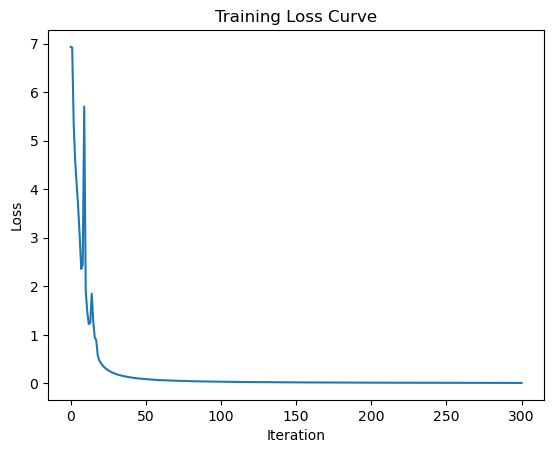

In [163]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

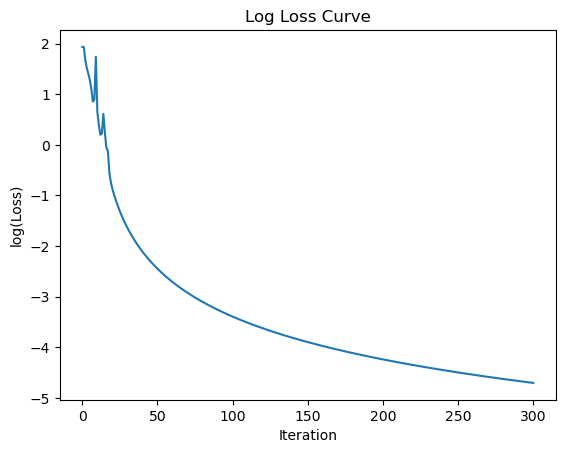

In [164]:
plt.figure()
plt.plot(np.log(losses))
plt.xlabel("Iteration")
plt.ylabel("log(Loss)")
plt.title("Log Loss Curve")
plt.show()

In [165]:
def evaluate_accuracy(params, Xs, Ys):
    H0 = np.zeros((1, hidden_dim))
    Zs, _ = rnn_forward(params, [Xs[t] for t in range(seq_len)], H0)
    
    correct = 0
    total = 0
    
    for t in range(seq_len):
        preds = np.argmax(Zs[t], axis=1)
        correct += np.sum(preds == Ys[t])
        total += len(preds)
    
    return correct / total

In [166]:
acc = evaluate_accuracy(params, Xs, Ys)
print("Training Accuracy:", acc)

Training Accuracy: 1.0


In [167]:
H0 = np.zeros((1, hidden_dim))
Zs, _ = rnn_forward(params, [Xs[t] for t in range(seq_len)], H0)

for t in range(seq_len):
    pred = np.argmax(Zs[t], axis=1)
    print(f"t={t} pred={pred}, true={Ys[t]}")

t=0 pred=[1], true=[1]
t=1 pred=[1], true=[1]
t=2 pred=[1], true=[1]
t=3 pred=[3], true=[3]
t=4 pred=[3], true=[3]


In [168]:
grad_norm = np.sqrt(sum(np.sum(g**2) for g in grads))
print("Gradient Norm:", grad_norm)

Gradient Norm: 2.600734118282368
